# Weather Trend Forecasting

This notebook forecasts the **country-balanced global daily mean temperature**.

- missing calendar dates are interpolated before modelling;
- all reported test forecasts are **rolling one-day-ahead forecasts**;
- machine-learning models use only information available before the predicted date;
- model and ensemble choices use a validation period, not the final test period;
- a separate 30-day forecast is created beyond the end of the dataset;
- an Augmented Dickey-Fuller test justifies the SARIMA differencing order;


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TEST_DAYS = 60
VALIDATION_DAYS = 60
MIN_COUNTRIES_PER_DAY = 150

## 1. Load the data

The notebook first looks for `weather_cleaned.csv`. If it is not found, it uses the original CSV and applies a minimal temperature plausibility check so the notebook can still run independently.

In [2]:
def find_file(filename):
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / filename
        if candidate.exists():
            return candidate
    return None

cleaned_path = find_file("weather_cleaned.csv")
raw_path = find_file("GlobalWeatherRepository.csv")

if cleaned_path is not None:
    data_path = cleaned_path
    df = pd.read_csv(data_path, parse_dates=["last_updated"])
    source = "weather_cleaned.csv"
elif raw_path is not None:
    data_path = raw_path
    df = pd.read_csv(data_path, parse_dates=["last_updated"])
    invalid_temperature = ~df["temperature_celsius"].between(-60, 60)
    df.loc[invalid_temperature, "temperature_celsius"] = np.nan
    source = "GlobalWeatherRepository.csv"
else:
    raise FileNotFoundError(
        "Place weather_cleaned.csv or GlobalWeatherRepository.csv in the project folder."
    )

print("Source:", source)
print("Dataset shape:", df.shape)
print("Date range:", df["last_updated"].min(), "to", df["last_updated"].max())
print("Countries:", df["country"].nunique())
print("Locations:", df["location_name"].nunique())

Source: weather_cleaned.csv
Dataset shape: (153586, 38)
Date range: 2024-05-16 02:45:00 to 2026-07-18 19:00:00
Countries: 186
Locations: 217


In [3]:
df

,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,month_name,day_of_week,hour
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338.0,NNW,1012.0,0.0,24.0,30.0,25.3,10.0,7.0,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,13
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320.0,NW,1012.0,0.1,94.0,75.0,19.0,10.0,5.0,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280.0,W,1011.0,0.0,29.0,0.0,24.6,10.0,5.0,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215.0,SW,1007.0,0.3,61.0,100.0,3.8,2.0,2.0,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150.0,SSE,1011.0,0.0,89.0,50.0,28.7,10.0,8.0,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153581,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,2026-07-18 01:45:00,17.9,Mist,6.1,155.0,SSE,1017.0,0.0,97.0,56.0,12.7,2.0,0.0,12.9,549.0,24.0,5.3,1.7,1.7,2.6,1,1,06:14 AM,06:53 PM,10:03 AM,10:26 PM,Waxing Crescent,18.0,2026,7,July,Saturday,1
153582,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,2026-07-18 12:45:00,35.1,Cloudy,9.0,251.0,WSW,1001.0,0.0,56.0,25.0,45.3,10.0,11.7,10.4,403.0,190.0,5.0,16.0,27.3,31.8,2,3,05:25 AM,06:40 PM,09:01 AM,09:36 PM,Waxing Crescent,14.0,2026,7,July,Saturday,12
153583,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,2026-07-18 08:45:00,22.8,Sunny,6.1,352.0,N,1013.0,0.0,30.0,17.0,17.6,10.0,2.4,7.1,108.0,90.0,1.5,3.1,28.8,91.0,2,3,05:41 AM,06:37 PM,09:20 AM,09:49 PM,Waxing Crescent,16.0,2026,7,July,Saturday,8
153584,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,2026-07-18 07:45:00,12.7,Cloudy,7.9,86.0,E,1023.0,0.0,54.0,78.0,8.8,10.0,0.2,16.0,211.0,66.0,2.1,2.7,13.4,14.8,1,2,06:33 AM,05:52 PM,09:35 AM,09:53 PM,Waxing Crescent,16.0,2026,7,July,Saturday,7


## 2. Build a country-balanced daily temperature series

A country may contain several sampled locations. To prevent those countries from receiving extra weight:

1. average temperature within each country and date;
2. average those country-level values to obtain one global daily value.

Dates with fewer than 150 represented countries are excluded before the complete daily calendar is restored.

In [4]:
forecast_df = df[
    ["last_updated", "country", "location_name", "temperature_celsius"]
].dropna(subset=["last_updated", "country", "temperature_celsius"]).copy()

forecast_df["date"] = forecast_df["last_updated"].dt.floor("D")

daily_coverage = forecast_df.groupby("date").agg(
    observations=("temperature_celsius", "size"),
    countries=("country", "nunique"),
    locations=("location_name", "nunique")
)

valid_dates = daily_coverage.index[
    daily_coverage["countries"] >= MIN_COUNTRIES_PER_DAY
]

print("Total observed dates:", len(daily_coverage))
print("Dates meeting coverage threshold:", len(valid_dates))
print("Excluded low-coverage dates:", len(daily_coverage) - len(valid_dates))

display(daily_coverage.sort_values("countries").head(10))

Total observed dates: 793
Dates meeting coverage threshold: 788
Excluded low-coverage dates: 5


,observations,countries,locations
date,,,
2026-01-19,1,1,1
2024-07-21,6,6,6
2026-03-09,98,97,98
2026-03-08,114,110,114
2024-07-13,124,122,124
2025-01-07,159,150,159
2024-11-01,163,154,163
2024-07-23,164,156,164
2026-06-04,163,160,160


In [5]:
country_daily = (
    forecast_df.groupby(["date", "country"])["temperature_celsius"]
    .mean()
    .reset_index()
)

daily_temperature = (
    country_daily[country_daily["date"].isin(valid_dates)]
    .groupby("date")["temperature_celsius"]
    .mean()
    .sort_index()
)

complete_index = pd.date_range(
    daily_temperature.index.min(),
    daily_temperature.index.max(),
    freq="D"
)

daily_temperature = daily_temperature.reindex(complete_index)
daily_temperature.index.name = "date"
daily_temperature.name = "temperature_celsius"

missing_dates = daily_temperature[daily_temperature.isna()].index
print("Missing calendar dates before interpolation:", len(missing_dates))
print(list(missing_dates))

# Time interpolation fixes the missing-date issue in the original notebook.
daily_temperature = (
    daily_temperature
    .interpolate(method="time", limit_direction="both")
    .asfreq("D")
)

assert daily_temperature.isna().sum() == 0
print("Final daily observations:", len(daily_temperature))

Missing calendar dates before interpolation: 6
[Timestamp('2024-07-13 00:00:00'), Timestamp('2024-07-21 00:00:00'), Timestamp('2024-07-22 00:00:00'), Timestamp('2026-01-19 00:00:00'), Timestamp('2026-03-08 00:00:00'), Timestamp('2026-03-09 00:00:00')]
Final daily observations: 794


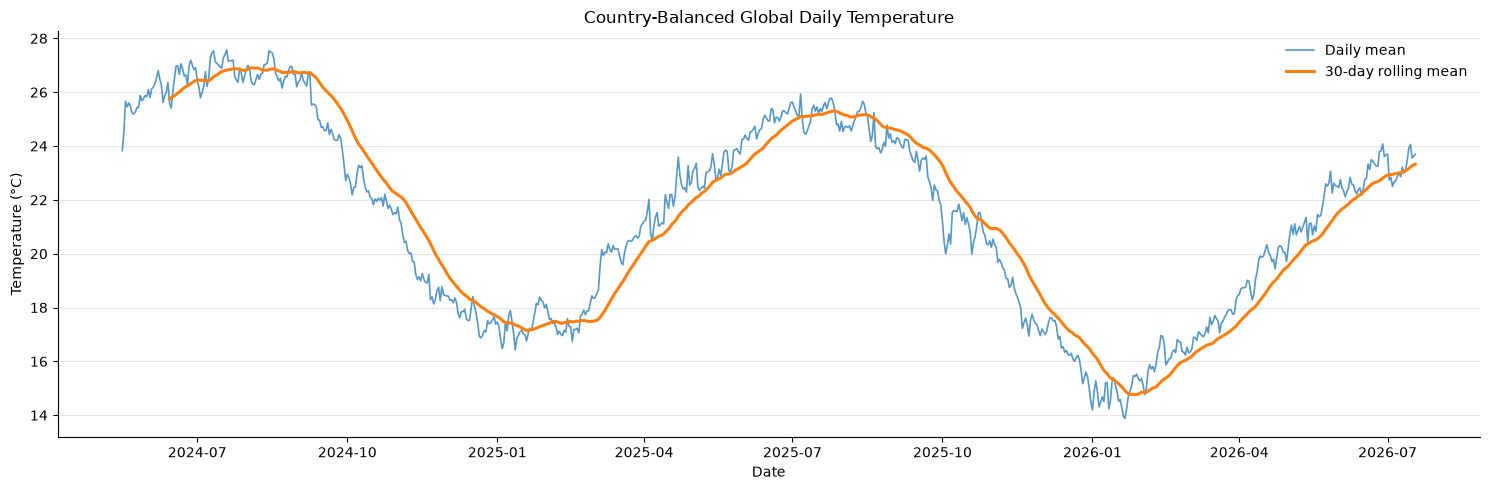

In [6]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily_temperature, linewidth=1.2, alpha=0.75, label="Daily mean")
ax.plot(
    daily_temperature.rolling(30).mean(),
    linewidth=2.2,
    label="30-day rolling mean"
)
ax.set_title("Country-Balanced Global Daily Temperature")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Autocorrelation

High short-lag autocorrelation means recent temperatures should provide a strong forecasting signal.

In [7]:
for lag in [1, 7, 30]:
    print(
        f"Lag {lag} autocorrelation:",
        round(daily_temperature.autocorr(lag=lag), 3)
    )

Lag 1 autocorrelation: 0.996
Lag 7 autocorrelation: 0.979
Lag 30 autocorrelation: 0.875


## 3. Chronological train, validation and test split

- **Training:** fits the models.
- **Validation:** selects the ensemble weight.
- **Test:** provides the final unbiased comparison.

In [8]:
test_start = daily_temperature.index[-TEST_DAYS]
train_series = daily_temperature.loc[: test_start - pd.Timedelta(days=1)]
test_series = daily_temperature.loc[test_start:]

validation_start = train_series.index[-VALIDATION_DAYS]
subtrain_series = train_series.loc[: validation_start - pd.Timedelta(days=1)]
validation_series = train_series.loc[validation_start:]

split_table = pd.DataFrame({
    "Period": ["Training", "Validation", "Test"],
    "Start": [
        subtrain_series.index.min(),
        validation_series.index.min(),
        test_series.index.min()
    ],
    "End": [
        subtrain_series.index.max(),
        validation_series.index.max(),
        test_series.index.max()
    ],
    "Observations": [
        len(subtrain_series),
        len(validation_series),
        len(test_series)
    ]
})

display(split_table)

,Period,Start,End,Observations
0,Training,2024-05-16,2026-03-20,674
1,Validation,2026-03-21,2026-05-19,60
2,Test,2026-05-20,2026-07-18,60


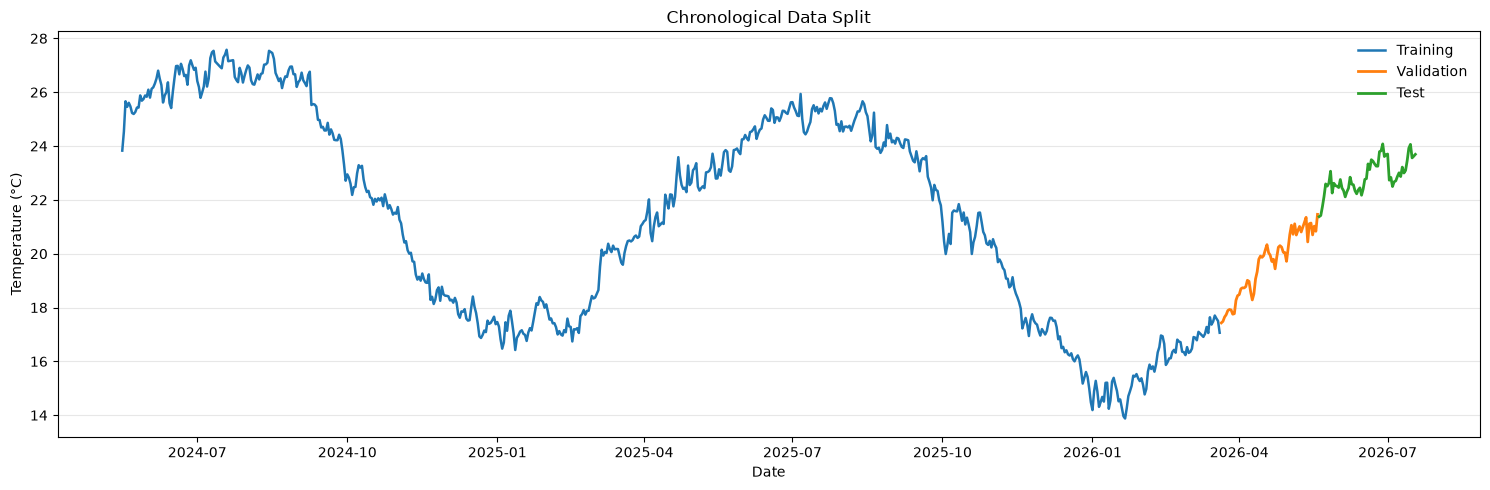

In [9]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(subtrain_series, label="Training", linewidth=1.8)
ax.plot(validation_series, label="Validation", linewidth=2)
ax.plot(test_series, label="Test", linewidth=2)
ax.set_title("Chronological Data Split")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Stationarity check

SARIMA's `d=1` (first differencing) should be justified rather than assumed. An Augmented Dickey-Fuller test checks this: a large negative test statistic and a p-value below 0.05 mean the series is stationary.

In [10]:
from statsmodels.tsa.stattools import adfuller

def report_adf(series, label):
    stat, pvalue, _, _, crit_values, _ = adfuller(series.dropna(), autolag="AIC")
    print(f"{label}")
    print(f"  ADF statistic: {stat:.4f}")
    print(f"  p-value: {pvalue:.4f}")
    print(f"  Critical values: {crit_values}")
    print(f"  Stationary at 5%: {'Yes' if pvalue < 0.05 else 'No'}\n")

report_adf(train_series, "Level series (no differencing)")
report_adf(train_series.diff(), "First-differenced series")

Level series (no differencing)
  ADF statistic: -1.2754
  p-value: 0.6403
  Critical values: {'1%': np.float64(-3.4393396487377155), '5%': np.float64(-2.865507363200066), '10%': np.float64(-2.5688826684180897)}
  Stationary at 5%: No

First-differenced series
  ADF statistic: -17.8365
  p-value: 0.0000
  Critical values: {'1%': np.float64(-3.4393396487377155), '5%': np.float64(-2.865507363200066), '10%': np.float64(-2.5688826684180897)}
  Stationary at 5%: Yes



**Takeaway:** The level series is non-stationary (ADF statistic -1.28, p = 0.6403 — well above 0.05), while the first-differenced series is clearly stationary (ADF statistic -17.84, p < 0.0001, far below the 5% critical value of -2.87). This confirms first differencing is necessary and sufficient to stabilize the series, supporting the SARIMA specification's `d=1` used below.


## 4. Evaluation and leakage-safe features

The machine-learning models use only lagged temperatures, trailing statistics and calendar features. They do not use humidity, pressure or other measurements from the day being predicted.

In [11]:
def evaluate_forecast(actual, predicted):
    actual, predicted = actual.align(predicted, join="inner")
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "MAPE": np.mean(np.abs((actual - predicted) / actual)) * 100,
        "sMAPE": np.mean(
            2 * np.abs(actual - predicted)
            / (np.abs(actual) + np.abs(predicted))
        ) * 100
    }

LAGS = [1, 2, 3, 7, 14, 30, 60]
WINDOWS = [7, 14, 30]

def make_features(history, target_date):
    row = {}

    for lag in LAGS:
        row[f"temp_lag_{lag}"] = history.iloc[-lag]

    for window in WINDOWS:
        trailing = history.iloc[-window:]
        row[f"rolling_mean_{window}"] = trailing.mean()
        row[f"rolling_std_{window}"] = trailing.std()
        row[f"rolling_min_{window}"] = trailing.min()
        row[f"rolling_max_{window}"] = trailing.max()

    day_of_year = target_date.dayofyear
    row["doy_sin"] = np.sin(2 * np.pi * day_of_year / 365.25)
    row["doy_cos"] = np.cos(2 * np.pi * day_of_year / 365.25)
    row["trend"] = target_date.toordinal()

    return row

def make_supervised(series):
    rows, targets, dates = [], [], []
    start = max(max(LAGS), max(WINDOWS))

    for position in range(start, len(series)):
        date = series.index[position]
        rows.append(make_features(series.iloc[:position], date))
        targets.append(series.iloc[position])
        dates.append(date)

    X = pd.DataFrame(rows, index=dates)
    y = pd.Series(targets, index=dates, name="target")
    return X, y

def make_online_features(history, future_actuals):
    """Create one-day-ahead features and reveal each actual after prediction."""
    working_history = history.copy()
    rows = []

    for date, actual_value in future_actuals.items():
        rows.append(make_features(working_history, date))
        working_history.loc[date] = actual_value

    return pd.DataFrame(rows, index=future_actuals.index)

## 5. Rolling statistical forecasts

Each model predicts one day ahead, then receives the actual observation before forecasting the next day. This makes the comparison fair.

In [12]:
def rolling_holt(history, future_actuals):
    working_history = history.asfreq("D").copy()
    predictions = []

    for date, actual_value in future_actuals.items():
        model = Holt(
            working_history,
            damped_trend=True,
            initialization_method="estimated"
        ).fit(optimized=True)

        predictions.append(float(model.forecast(1).iloc[0]))
        working_history.loc[date] = actual_value

    return pd.Series(predictions, index=future_actuals.index)

def rolling_sarima(history, future_actuals):
    named_history = history.asfreq("D").rename("temperature")

    fitted = SARIMAX(
        named_history,
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    predictions = []

    for date, actual_value in future_actuals.items():
        predictions.append(float(fitted.forecast(1).iloc[0]))

        new_observation = pd.Series(
            [actual_value],
            index=pd.DatetimeIndex([date]),
            name="temperature"
        )
        fitted = fitted.append(new_observation, refit=False)

    return pd.Series(predictions, index=future_actuals.index)

## 6. Validation predictions and ensemble selection

Ridge regression is normalized with `StandardScaler`. Random Forest is included as a nonlinear model. The ensemble weight is selected only on validation MAE.

In [13]:
X_subtrain, y_subtrain = make_supervised(subtrain_series)
X_validation = make_online_features(subtrain_series, validation_series)

ridge_validation_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
ridge_validation_model.fit(X_subtrain, y_subtrain)

rf_validation_model = RandomForestRegressor(
    n_estimators=250,
    max_depth=6,
    min_samples_leaf=3,
    max_features=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_validation_model.fit(X_subtrain, y_subtrain)

validation_predictions = {
    "Rolling Naive": daily_temperature.shift(1).loc[validation_series.index],
    "Seasonal Naive (7-day)": daily_temperature.shift(7).loc[validation_series.index],
    "Holt Damped": rolling_holt(subtrain_series, validation_series),
    "SARIMA": rolling_sarima(subtrain_series, validation_series),
    "Ridge": pd.Series(
        ridge_validation_model.predict(X_validation),
        index=validation_series.index
    ),
    "Random Forest": pd.Series(
        rf_validation_model.predict(X_validation),
        index=validation_series.index
    )
}

validation_results = pd.DataFrame([
    {"Model": name, **evaluate_forecast(validation_series, prediction)}
    for name, prediction in validation_predictions.items()
]).sort_values(["MAE", "RMSE"])

display(validation_results.round(4))

,Model,MAE,RMSE,MAPE,sMAPE
4,Ridge,0.2183,0.2900,1.1027,1.0983
2,Holt Damped,0.2376,0.3038,1.1961,1.1983
0,Rolling Naive,0.2407,0.3060,1.2116,1.2148
3,SARIMA,0.2422,0.3041,1.2199,1.2235
5,Random Forest,0.3205,0.3971,1.6109,1.6126
1,Seasonal Naive (7-day),0.4977,0.6308,2.5366,2.5854


In [14]:
weight_results = []

for ridge_weight in np.linspace(0, 1, 21):
    ensemble_prediction = (
        ridge_weight * validation_predictions["Ridge"]
        + (1 - ridge_weight) * validation_predictions["Rolling Naive"]
    )

    weight_results.append({
        "Ridge weight": ridge_weight,
        "Naive weight": 1 - ridge_weight,
        **evaluate_forecast(validation_series, ensemble_prediction)
    })

weight_results = pd.DataFrame(weight_results).sort_values(["MAE", "RMSE"])
best_ridge_weight = float(weight_results.iloc[0]["Ridge weight"])
best_naive_weight = 1 - best_ridge_weight

print(
    f"Selected ensemble: {best_ridge_weight:.2f} Ridge + "
    f"{best_naive_weight:.2f} Rolling Naive"
)
display(weight_results.head(5).round(4))

Selected ensemble: 0.85 Ridge + 0.15 Rolling Naive


,Ridge weight,Naive weight,MAE,RMSE,MAPE,sMAPE
17,0.85,0.15,0.2173,0.2870,1.0958,1.0925
18,0.90,0.10,0.2175,0.2878,1.0974,1.0937
16,0.80,0.20,0.2175,0.2864,1.0966,1.0936
15,0.75,0.25,0.2178,0.2860,1.0973,1.0947
19,0.95,0.05,0.2179,0.2888,1.1001,1.0960


## 7. Final test comparison

The test period is evaluated once after the workflow and ensemble weight have been decided.

In [15]:
X_train, y_train = make_supervised(train_series)
X_test = make_online_features(train_series, test_series)

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
ridge_model.fit(X_train, y_train)

rf_model = RandomForestRegressor(
    n_estimators=250,
    max_depth=6,
    min_samples_leaf=3,
    max_features=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

test_predictions = {
    "Rolling Naive": daily_temperature.shift(1).loc[test_series.index],
    "Seasonal Naive (7-day)": daily_temperature.shift(7).loc[test_series.index],
    "Holt Damped": rolling_holt(train_series, test_series),
    "SARIMA": rolling_sarima(train_series, test_series),
    "Ridge": pd.Series(ridge_model.predict(X_test), index=test_series.index),
    "Random Forest": pd.Series(rf_model.predict(X_test), index=test_series.index)
}

test_predictions["Ridge + Naive Ensemble"] = (
    best_ridge_weight * test_predictions["Ridge"]
    + best_naive_weight * test_predictions["Rolling Naive"]
)

comparison = pd.DataFrame([
    {"Model": name, **evaluate_forecast(test_series, prediction)}
    for name, prediction in test_predictions.items()
]).sort_values(["MAE", "RMSE"]).reset_index(drop=True)

display(comparison.round(4))

,Model,MAE,RMSE,MAPE,sMAPE
0,Ridge + Naive Ensemble,0.2206,0.2918,0.9665,0.9639
1,SARIMA,0.2233,0.2991,0.9760,0.9765
2,Holt Damped,0.2262,0.2990,0.9895,0.9887
3,Ridge,0.2276,0.2952,0.9980,0.9948
4,Rolling Naive,0.2293,0.3008,1.0027,1.0027
5,Random Forest,0.2774,0.3552,1.2166,1.2182
6,Seasonal Naive (7-day),0.6190,0.7612,2.7028,2.7333


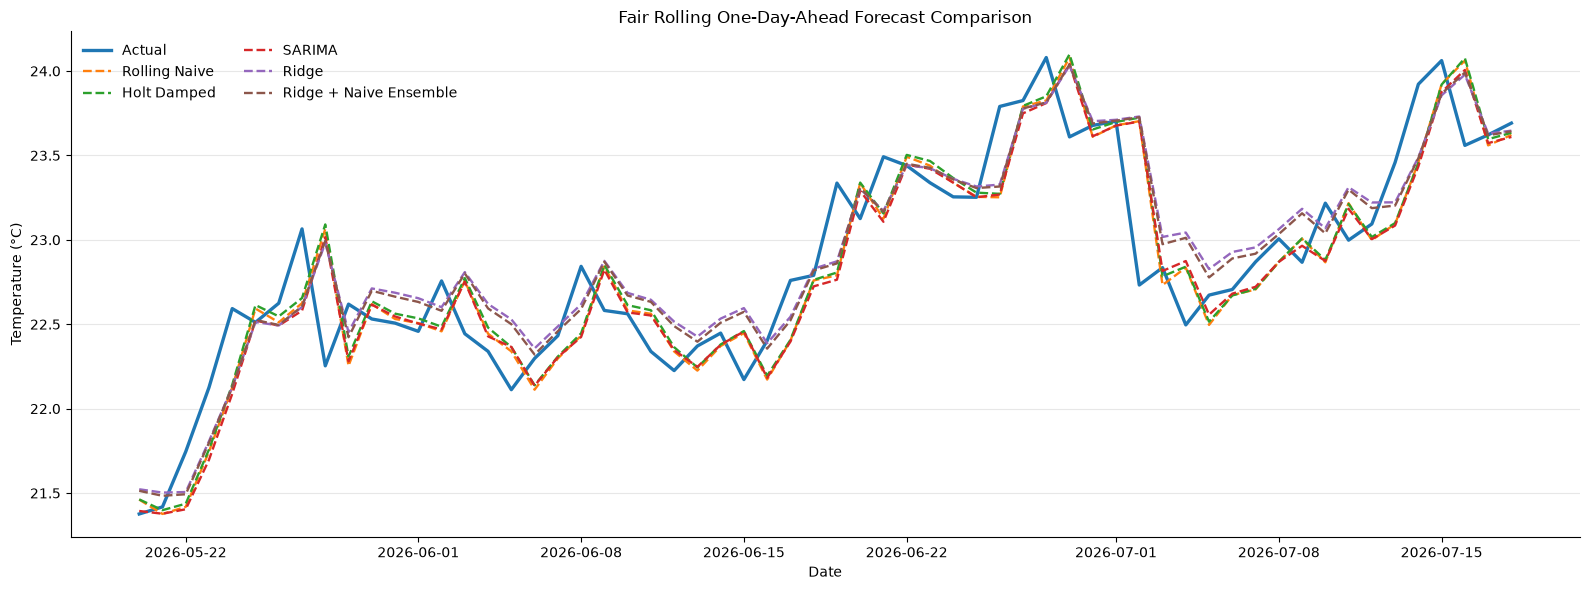

In [16]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(test_series, linewidth=2.4, label="Actual")

for model_name in [
    "Rolling Naive",
    "Holt Damped",
    "SARIMA",
    "Ridge",
    "Ridge + Naive Ensemble"
]:
    ax.plot(
        test_predictions[model_name],
        linestyle="--",
        linewidth=1.7,
        label=model_name
    )

ax.set_title("Fair Rolling One-Day-Ahead Forecast Comparison")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(frameon=False, ncol=2)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation

The rolling naive model is a strong baseline because daily global temperature changes gradually. A more advanced model should only be described as better when it achieves lower error under the same one-day-ahead evaluation setup.

## 8. Feature importance

Two simple views are provided:

- standardized Ridge coefficients for linear influence;
- Random Forest importance for nonlinear influence.

In [17]:
ridge_coefficients = pd.Series(
    ridge_model.named_steps["ridge"].coef_,
    index=X_train.columns,
    name="Ridge coefficient"
).sort_values(key=np.abs, ascending=False)

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns,
    name="Random Forest importance"
).sort_values(ascending=False)

print("Top Ridge features")
display(ridge_coefficients.head(12).to_frame().round(4))

print("Top Random Forest features")
display(rf_importance.head(12).to_frame().round(4))

Top Ridge features


,Ridge coefficient
temp_lag_1,2.4239
doy_cos,-0.4752
rolling_max_14,0.2659
rolling_min_7,0.2463
doy_sin,-0.1968
trend,-0.1715
temp_lag_60,-0.1520
rolling_max_30,0.1424
rolling_mean_30,-0.1340
rolling_mean_7,0.1319


Top Random Forest features


,Random Forest importance
temp_lag_1,0.7434
temp_lag_2,0.0979
rolling_min_7,0.0589
rolling_mean_7,0.0320
rolling_max_7,0.0229
rolling_min_14,0.0169
temp_lag_3,0.0145
trend,0.0088
rolling_mean_14,0.0010
rolling_mean_30,0.0008


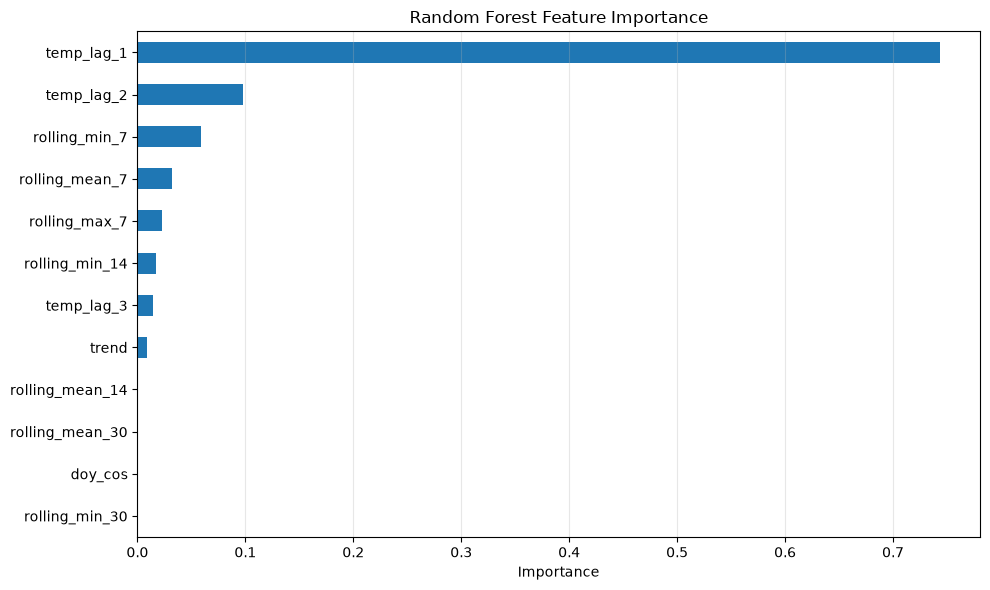

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
rf_importance.head(12).sort_values().plot(kind="barh", ax=ax)
ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Forecast the next 30 days

Backtesting uses known historical actuals. For dates beyond the dataset, the Ridge forecast is generated recursively: each predicted value becomes an input for later dates.

In [19]:
def recursive_forecast(model, history, future_dates, feature_columns):
    working_history = history.copy()
    predictions = []

    for date in future_dates:
        row = pd.DataFrame(
            [make_features(working_history, date)],
            index=[date]
        )[feature_columns]

        prediction = float(model.predict(row)[0])
        predictions.append(prediction)
        working_history.loc[date] = prediction

    return pd.Series(predictions, index=future_dates, name="Forecast")

X_all, y_all = make_supervised(daily_temperature)

future_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])
future_model.fit(X_all, y_all)

future_dates = pd.date_range(
    daily_temperature.index.max() + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

future_forecast = recursive_forecast(
    future_model,
    daily_temperature,
    future_dates,
    X_all.columns
)

# A simple uncertainty band based on Ridge test residuals.
residual_std = (test_series - test_predictions["Ridge"]).std(ddof=1)
horizon = np.arange(1, len(future_forecast) + 1)
margin = 1.96 * residual_std * np.sqrt(horizon)

future_output = pd.DataFrame({
    "forecast_temperature_celsius": future_forecast,
    "lower_95_heuristic": future_forecast - margin,
    "upper_95_heuristic": future_forecast + margin
})

display(future_output.head(10).round(3))

,forecast_temperature_celsius,lower_95_heuristic,upper_95_heuristic
2026-07-19,23.681,23.110,24.252
2026-07-20,23.702,22.894,24.510
2026-07-21,23.684,22.694,24.673
2026-07-22,23.650,22.507,24.793
2026-07-23,23.620,22.343,24.897
2026-07-24,23.599,22.200,24.999
2026-07-25,23.576,22.064,25.087
2026-07-26,23.519,21.903,25.134
2026-07-27,23.493,21.780,25.207
2026-07-28,23.444,21.637,25.251


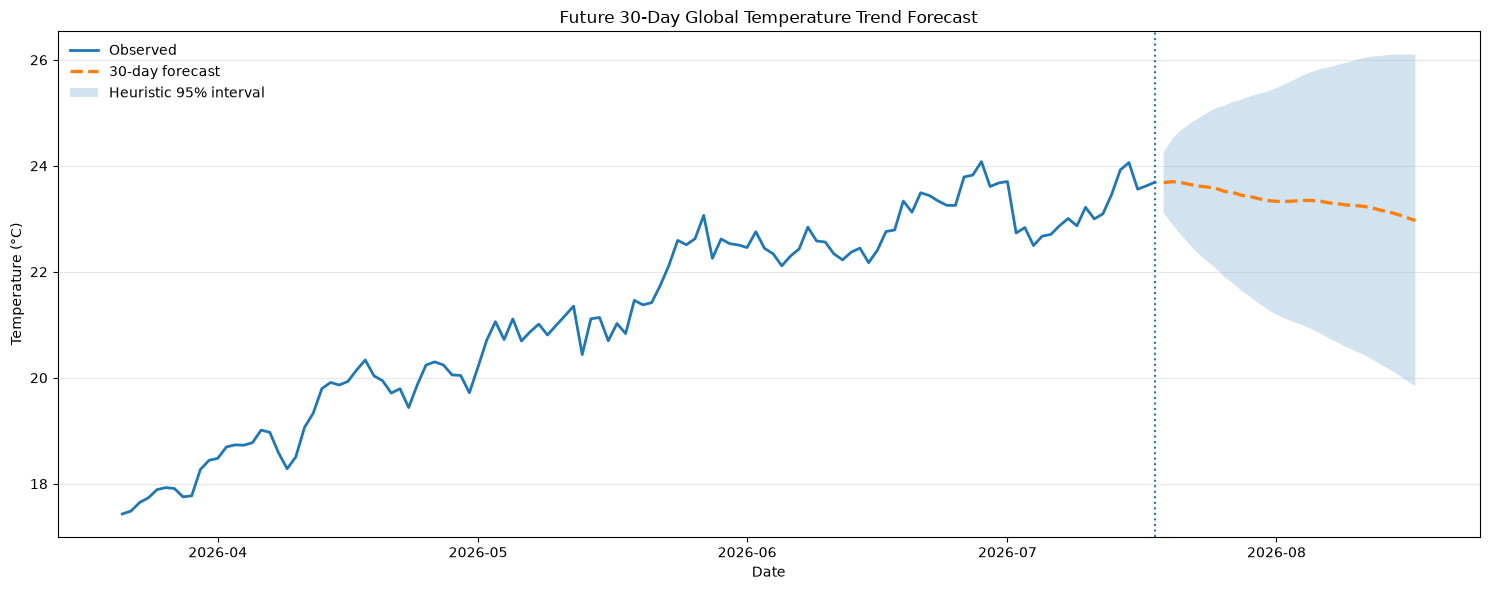

In [20]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily_temperature.iloc[-120:], linewidth=2, label="Observed")
ax.plot(
    future_output["forecast_temperature_celsius"],
    linestyle="--",
    linewidth=2.4,
    label="30-day forecast"
)
ax.fill_between(
    future_output.index,
    future_output["lower_95_heuristic"],
    future_output["upper_95_heuristic"],
    alpha=0.2,
    label="Heuristic 95% interval"
)
ax.axvline(daily_temperature.index.max(), linestyle=":")
ax.set_title("Future 30-Day Global Temperature Trend Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Final notes for the report

- This is a **global temperature trend model**, not a city-level weather service.
- The final metrics describe rolling next-day forecasting over the test period.
- The future 30-day section is a separate recursive forecast beyond the observed data.
- Complex models should not be presented as better unless they outperform the rolling naive baseline.
- The uncertainty band in Section 9 is heuristic and should not be described as a fully calibrated probabilistic interval.
- The Augmented Dickey-Fuller test in Section 3 confirms the raw series is non-stationary and first differencing resolves this, supporting SARIMA's `d=1`.